In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
# Create a dedicated folder for this assignment's checkpoints
checkpoint_dir = '/content/drive/MyDrive/ATML_PA0/checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)
print("Checkpoint directory ready:", checkpoint_dir)



Mounted at /content/drive
Checkpoint directory ready: /content/drive/MyDrive/ATML_PA0/checkpoints


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import time

import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


# Task 1.1:

In [3]:
# ResNet expects 224x224 3-channel images normalized with ImageNet stats
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
val_dataset   = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Use a reasonable batch size — reduce if you hit OOM
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")

100%|██████████| 170M/170M [19:46<00:00, 144kB/s]


Train samples: 50000, Val samples: 10000


In [4]:
model = models.resnet152(weights=models.ResNet152_Weights.IMAGENET1K_V2)

# Freeze all backbone parameters
for param in model.parameters():
    param.requires_grad = False

# Replace final FC layer: 2048 -> 10 classes for CIFAR-10
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 10)  # this new layer has requires_grad=True by default

model = model.to(device)

# Sanity check: confirm only fc params are trainable
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable_params} / {total_params}")

Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:01<00:00, 162MB/s]


Trainable params: 20490 / 58164298


In [5]:
criterion = nn.CrossEntropyLoss()
# Only pass trainable (fc layer) params to the optimizer
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

In [6]:
def save_checkpoint(model, optimizer, epoch, history, filename="task1_1_baseline.pt"):
    path = os.path.join(checkpoint_dir, filename)
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'history': history,
    }, path)
    print(f"Checkpoint saved to {path}")

def load_checkpoint(model, optimizer, filename="task1_1_baseline.pt"):
    path = os.path.join(checkpoint_dir, filename)
    if not os.path.exists(path):
        print("No checkpoint found at", path)
        return model, optimizer, 0, {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch']
    history = checkpoint['history']
    print(f"Checkpoint loaded from {path}, resuming from epoch {start_epoch}")
    return model, optimizer, start_epoch, history

In [7]:
# Optionally resume from a previous checkpoint
model, optimizer, start_epoch, history = load_checkpoint(model, optimizer)

num_epochs = 5  # total epochs you want to reach

for epoch in range(start_epoch, num_epochs):
    start = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    elapsed = time.time() - start
    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f} | "
          f"Time: {elapsed:.1f}s")

    # Save after every epoch so you never lose progress if Colab disconnects
    save_checkpoint(model, optimizer, epoch + 1, history)

Checkpoint loaded from /content/drive/MyDrive/ATML_PA0/checkpoints/task1_1_baseline.pt, resuming from epoch 5


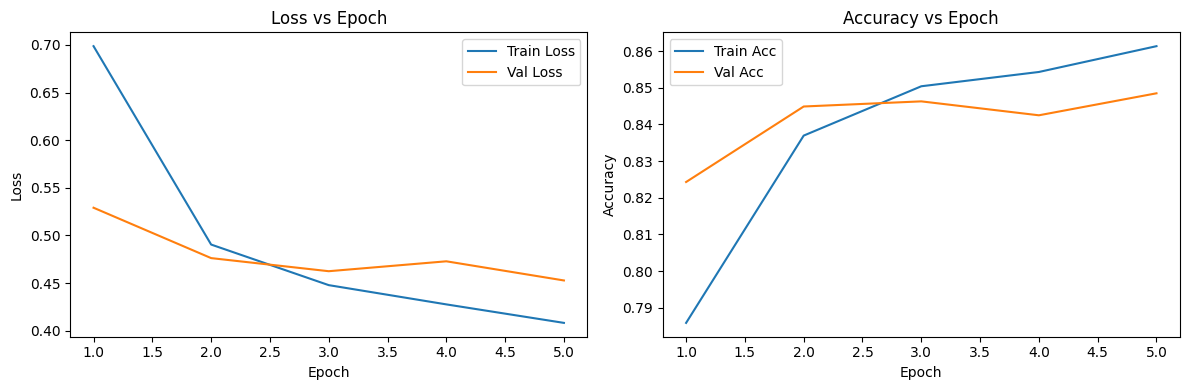

<Figure size 640x480 with 0 Axes>

In [8]:
import matplotlib.pyplot as plt

epochs_range = range(1, num_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, history["train_loss"], label="Train Loss")
axes[0].plot(epochs_range, history["val_loss"], label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss vs Epoch")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], label="Train Acc")
axes[1].plot(epochs_range, history["val_acc"], label="Val Acc")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy vs Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig("task1_1_baseline.png", dpi=150)
plt.show()

plt.savefig('/content/drive/MyDrive/ATML_PA0/task1_1_baseline.png', dpi=150)

# Task 1.2:

In [9]:
# ResNet-152 is built from Bottleneck blocks. Each block's forward pass normally
# computes: out = F(x) + identity(x), then applies ReLU.
# To "disable" the skip connection, we override forward to drop the "+ identity" step.

import types

def forward_no_skip(self, x):
    identity = x  # kept only in case downsample changes shape; unused in output

    out = self.conv1(x)
    out = self.bn1(out)
    out = self.relu(out)

    out = self.conv2(out)
    out = self.bn2(out)
    out = self.relu(out)

    out = self.conv3(out)
    out = self.bn3(out)

    # --- Skip connection disabled: normally we'd do out += identity here ---
    out = self.relu(out)
    return out


def disable_skip_connections(model, layer_names, block_indices):
    """
    layer_names: list like ['layer2', 'layer3'] — which ResNet stages to target
    block_indices: list of block indices within each stage to modify, e.g. [0, 1]
    Modifies model in-place and returns list of modified block identifiers (for logging).
    """
    modified = []
    for layer_name in layer_names:
        layer = getattr(model, layer_name)
        for idx in block_indices:
            if idx < len(layer):
                block = layer[idx]
                block.forward = types.MethodType(forward_no_skip, block)
                modified.append(f"{layer_name}[{idx}]")
    return modified

In [10]:
# Load a fresh pretrained ResNet-152 (separate from your Task 1.1 baseline model)
model_no_skip = models.resnet152(weights=models.ResNet152_Weights.IMAGENET1K_V2)

# Freeze backbone first (same as baseline)
for param in model_no_skip.parameters():
    param.requires_grad = False

# Disable skip connections in a few selected blocks
# Example: first 2 blocks of layer2 and layer3 (mid-depth blocks — good for observing effects)
modified_blocks = disable_skip_connections(
    model_no_skip,
    layer_names=['layer2', 'layer3'],
    block_indices=[0, 1]
)
print("Skip connections disabled in blocks:", modified_blocks)

# Replace final FC layer for CIFAR-10 (same as baseline)
num_features = model_no_skip.fc.in_features
model_no_skip.fc = nn.Linear(num_features, 10)

model_no_skip = model_no_skip.to(device)

trainable_params = sum(p.numel() for p in model_no_skip.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_no_skip.parameters())
print(f"Trainable params: {trainable_params} / {total_params}")

Skip connections disabled in blocks: ['layer2[0]', 'layer2[1]', 'layer3[0]', 'layer3[1]']
Trainable params: 20490 / 58164298


In [11]:
criterion = nn.CrossEntropyLoss()
optimizer_no_skip = optim.Adam(model_no_skip.fc.parameters(), lr=1e-3)

# NOTE: reuse train_loader, val_loader, train_one_epoch(), validate()
# from your Task 1.1 notebook — no need to redefine them here.

num_epochs = 5

history_no_skip = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(num_epochs):
    start = time.time()

    train_loss, train_acc = train_one_epoch(model_no_skip, train_loader, optimizer_no_skip, criterion, device)
    val_loss, val_acc = validate(model_no_skip, val_loader, criterion, device)

    history_no_skip["train_loss"].append(train_loss)
    history_no_skip["train_acc"].append(train_acc)
    history_no_skip["val_loss"].append(val_loss)
    history_no_skip["val_acc"].append(val_acc)

    elapsed = time.time() - start
    print(f"[No-Skip] Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f} | "
          f"Time: {elapsed:.1f}s")

    save_checkpoint(model_no_skip, optimizer_no_skip, epoch + 1, history_no_skip,
                     filename="task1_2_no_skip.pt")

[No-Skip] Epoch 1/5 | Train Loss: 2.2991, Train Acc: 0.1149 | Val Loss: 2.3366, Val Acc: 0.1275 | Time: 432.3s
Checkpoint saved to /content/drive/MyDrive/ATML_PA0/checkpoints/task1_2_no_skip.pt
[No-Skip] Epoch 2/5 | Train Loss: 2.2946, Train Acc: 0.1244 | Val Loss: 2.3284, Val Acc: 0.1304 | Time: 435.8s
Checkpoint saved to /content/drive/MyDrive/ATML_PA0/checkpoints/task1_2_no_skip.pt
[No-Skip] Epoch 3/5 | Train Loss: 2.2897, Train Acc: 0.1293 | Val Loss: 2.4420, Val Acc: 0.1344 | Time: 435.1s
Checkpoint saved to /content/drive/MyDrive/ATML_PA0/checkpoints/task1_2_no_skip.pt
[No-Skip] Epoch 4/5 | Train Loss: 2.2897, Train Acc: 0.1303 | Val Loss: 2.3631, Val Acc: 0.1259 | Time: 435.6s
Checkpoint saved to /content/drive/MyDrive/ATML_PA0/checkpoints/task1_2_no_skip.pt
[No-Skip] Epoch 5/5 | Train Loss: 2.2893, Train Acc: 0.1331 | Val Loss: 2.3785, Val Acc: 0.1351 | Time: 435.9s
Checkpoint saved to /content/drive/MyDrive/ATML_PA0/checkpoints/task1_2_no_skip.pt


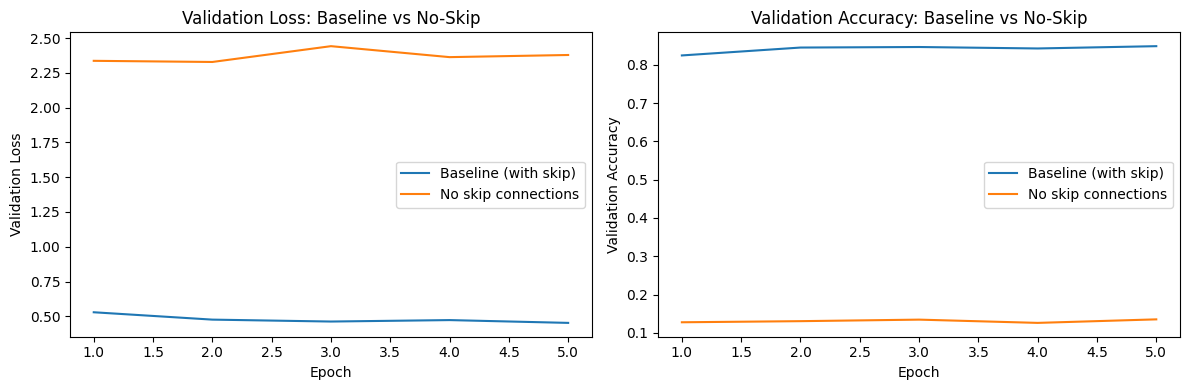

In [12]:
import matplotlib.pyplot as plt

# Assumes `history` (baseline, from Task 1.1) is still in memory or reloaded from checkpoint.
# If starting a fresh session, reload it first:
# _, _, _, history = load_checkpoint(model, optimizer, filename="task1_1_baseline.pt")

epochs_range = range(1, num_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, history["val_loss"], label="Baseline (with skip)")
axes[0].plot(epochs_range, history_no_skip["val_loss"], label="No skip connections")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Validation Loss")
axes[0].set_title("Validation Loss: Baseline vs No-Skip")
axes[0].legend()

axes[1].plot(epochs_range, history["val_acc"], label="Baseline (with skip)")
axes[1].plot(epochs_range, history_no_skip["val_acc"], label="No skip connections")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation Accuracy")
axes[1].set_title("Validation Accuracy: Baseline vs No-Skip")
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ATML_PA0/task1_2_comparison.png', dpi=150)
plt.show()

# Task 1.3:

In [13]:
# ResNet-152 structure: conv1 -> layer1 -> layer2 -> layer3 -> layer4 -> avgpool -> fc
# We'll grab outputs from:
#   layer1 (early)   - low-level features (edges, textures)
#   layer3 (middle)  - mid-level features (parts, patterns)
#   layer4 (late)    - high-level, semantic features

features = {}

def get_hook(name):
    def hook(module, input, output):
        # Global average pool each feature map down to a vector so we can run t-SNE/UMAP
        pooled = torch.nn.functional.adaptive_avg_pool2d(output, (1, 1))
        features[name] = pooled.squeeze(-1).squeeze(-1).detach().cpu()
    return hook

hooks = []
hooks.append(model.layer1.register_forward_hook(get_hook('early_layer1')))
hooks.append(model.layer3.register_forward_hook(get_hook('middle_layer3')))
hooks.append(model.layer4.register_forward_hook(get_hook('late_layer4')))

print("Hooks registered on: layer1 (early), layer3 (middle), layer4 (late)")

Hooks registered on: layer1 (early), layer3 (middle), layer4 (late)


In [14]:
# Collect a reasonable sample size for visualization (too many points makes t-SNE slow/messy)
num_samples_target = 2000

all_features = {'early_layer1': [], 'middle_layer3': [], 'late_layer4': []}
all_labels = []

collected = 0
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        _ = model(images)  # triggers hooks, populates `features` dict

        for key in all_features:
            all_features[key].append(features[key])
        all_labels.append(labels)

        collected += images.size(0)
        if collected >= num_samples_target:
            break

# Concatenate into single tensors/arrays
for key in all_features:
    all_features[key] = torch.cat(all_features[key], dim=0).numpy()
all_labels = torch.cat(all_labels, dim=0).numpy()

print("Collected samples:", all_labels.shape[0])
for key in all_features:
    print(f"{key} feature shape: {all_features[key].shape}")

# Remove hooks once done collecting (avoid interfering with later training/inference)
for h in hooks:
    h.remove()

Collected samples: 2048
early_layer1 feature shape: (2048, 256)
middle_layer3 feature shape: (2048, 1024)
late_layer4 feature shape: (2048, 2048)


In [15]:
!pip install umap-learn -q

In [16]:
from sklearn.manifold import TSNE

tsne_results = {}
for key, feats in all_features.items():
    print(f"Running t-SNE on {key}...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
    tsne_results[key] = tsne.fit_transform(feats)


import umap

umap_results = {}
for key, feats in all_features.items():
    print(f"Running UMAP on {key}...")
    reducer = umap.UMAP(n_components=2, random_state=42)
    umap_results[key] = reducer.fit_transform(feats)

Running t-SNE on early_layer1...
Running t-SNE on middle_layer3...
Running t-SNE on late_layer4...
Running UMAP on early_layer1...


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Running UMAP on middle_layer3...


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Running UMAP on late_layer4...


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


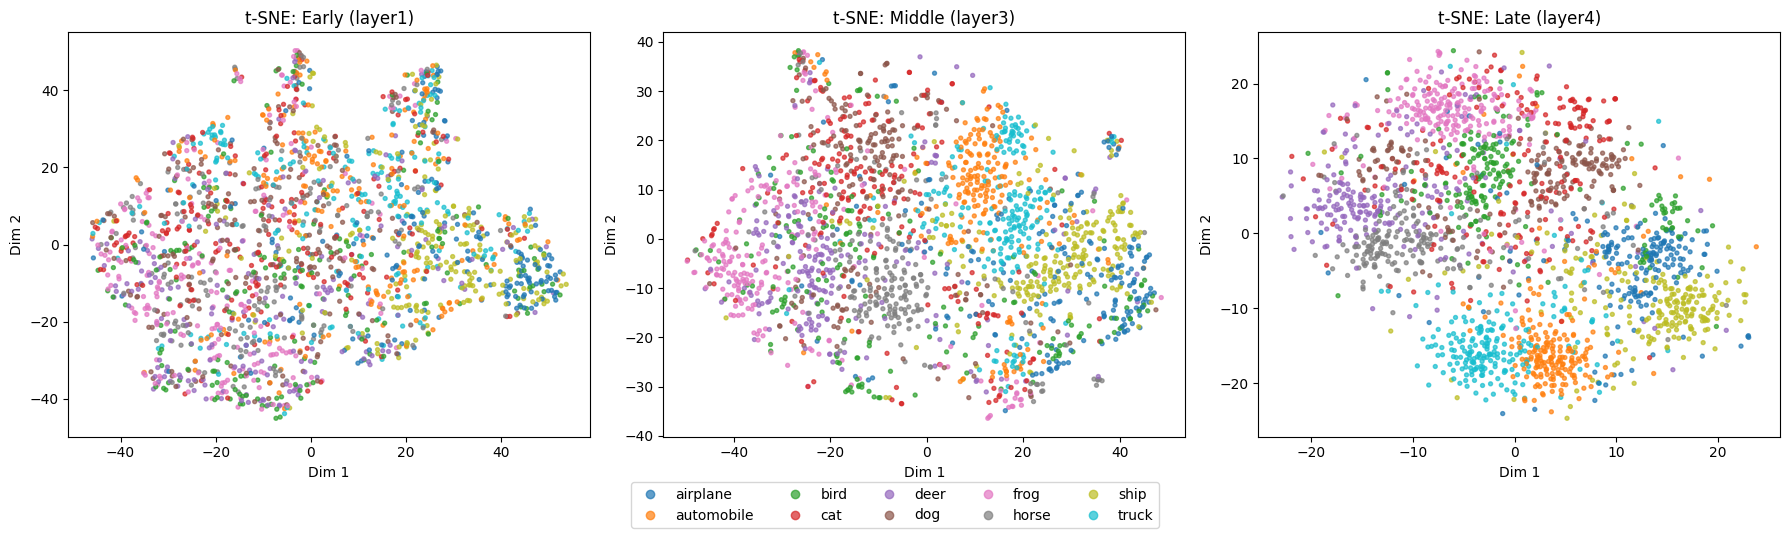

In [17]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
layer_order = ['early_layer1', 'middle_layer3', 'late_layer4']
titles = ['Early (layer1)', 'Middle (layer3)', 'Late (layer4)']

for ax, key, title in zip(axes, layer_order, titles):
    coords = tsne_results[key]
    scatter = ax.scatter(coords[:, 0], coords[:, 1], c=all_labels,
                          cmap='tab10', s=8, alpha=0.7)
    ax.set_title(f"t-SNE: {title}")
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")

# Shared legend
handles, _ = scatter.legend_elements()
fig.legend(handles, class_names, loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.08))

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ATML_PA0/task1_3_tsne_layers.png', dpi=150, bbox_inches='tight')
plt.show()

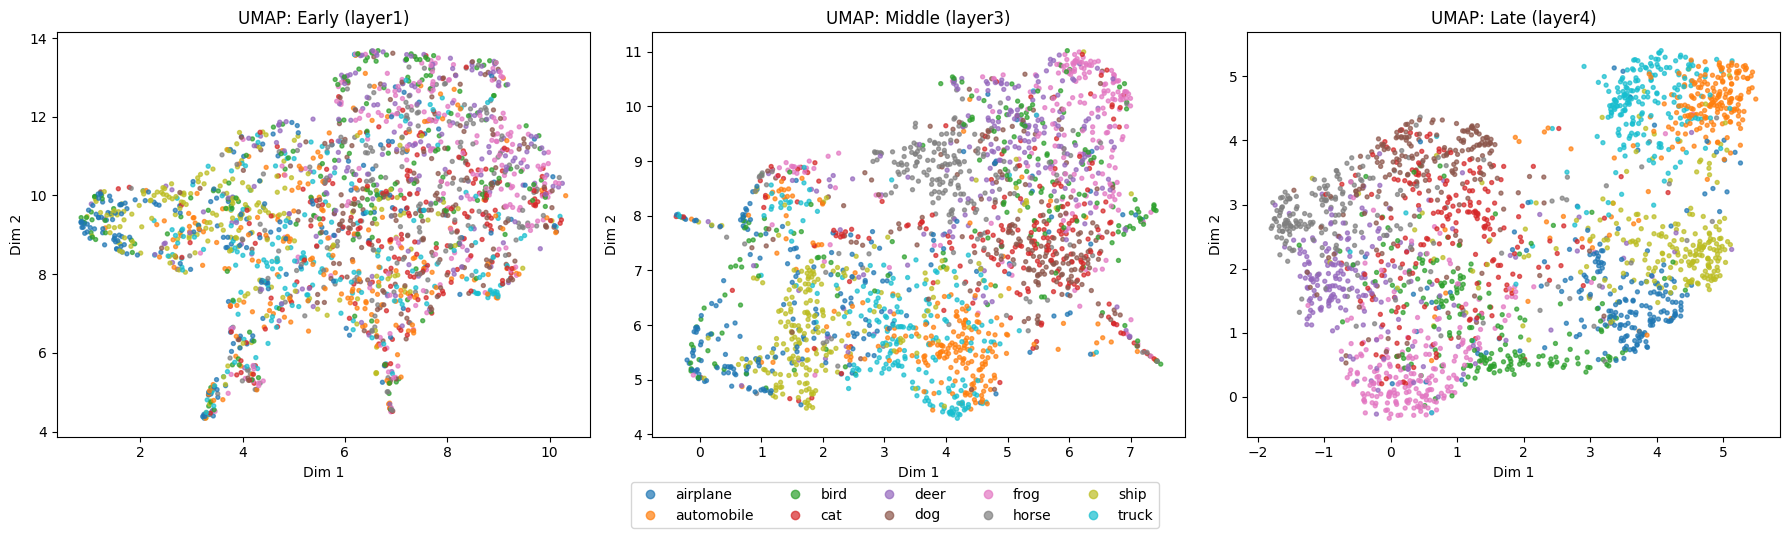

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, key, title in zip(axes, layer_order, titles):
    coords = umap_results[key]
    scatter = ax.scatter(coords[:, 0], coords[:, 1], c=all_labels,
                          cmap='tab10', s=8, alpha=0.7)
    ax.set_title(f"UMAP: {title}")
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")

handles, _ = scatter.legend_elements()
fig.legend(handles, class_names, loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.08))

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ATML_PA0/task1_3_umap_layers.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
from sklearn.metrics import silhouette_score

print("Silhouette scores (higher = better class separability):\n")
for key in layer_order:
    score = silhouette_score(all_features[key], all_labels)
    print(f"{key}: {score:.4f}")

Silhouette scores (higher = better class separability):

early_layer1: -0.0584
middle_layer3: 0.0000
late_layer4: 0.0114


# Task 1.4:


In [20]:
# === Task 1.4 — configuration =======================================
import os, json, time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DRIVE_DIR = '/content/drive/MyDrive/ATML_PA0'
CKPT_DIR  = os.path.join(DRIVE_DIR, 'checkpoints')
FEAT_DIR  = os.path.join(DRIVE_DIR, 'features')
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(FEAT_DIR, exist_ok=True)

CFG = {
    "img_size":     160,    # 224 -> 160 is ~2x cheaper; raise if you have quota to spare
    "train_subset": 10000,  # of 50000
    "val_subset":   2000,   # of 10000
    "batch_size":   64,
    "epochs":       5,
    "seed":         0,
}

torch.manual_seed(CFG["seed"])
np.random.seed(CFG["seed"])
torch.backends.cudnn.benchmark = True

# AMP imports with a fallback for older torch
try:
    from torch.amp import autocast, GradScaler
    def make_scaler(): return GradScaler('cuda')
    def amp_ctx():     return autocast('cuda')
except (ImportError, TypeError):
    from torch.cuda.amp import autocast as _ac, GradScaler as _gs
    def make_scaler(): return _gs()
    def amp_ctx():     return _ac()

print("Device:", device, "| config:", CFG)


Device: cuda | config: {'img_size': 160, 'train_subset': 10000, 'val_subset': 2000, 'batch_size': 64, 'epochs': 5, 'seed': 0}


In [21]:
# === Load CIFAR-10 directly onto the GPU as uint8 ====================
# Storing the raw 32x32 uint8 tensors on-GPU removes the CPU dataloader entirely:
# resizing and normalisation happen on the GPU, per batch.

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)


def stratified_subset(targets, n_total, num_classes=10, seed=0):
    """Equal number of samples per class, so accuracy stays comparable to the full set."""
    rng = np.random.RandomState(seed)
    targets = np.asarray(targets)
    per_class = n_total // num_classes
    idx = []
    for c in range(num_classes):
        cls_idx = np.where(targets == c)[0]
        idx.append(rng.choice(cls_idx, per_class, replace=False))
    idx = np.concatenate(idx)
    rng.shuffle(idx)
    return idx


def to_gpu_uint8(ds, n_total, seed):
    idx = stratified_subset(ds.targets, n_total, seed=seed)
    x = torch.from_numpy(ds.data[idx]).permute(0, 3, 1, 2).contiguous()   # N,3,32,32 uint8
    y = torch.tensor(np.asarray(ds.targets)[idx], dtype=torch.long)
    return x.to(device), y.to(device)


_train_raw = datasets.CIFAR10(root='./data', train=True,  download=True)
_val_raw   = datasets.CIFAR10(root='./data', train=False, download=True)

X_train, Y_train = to_gpu_uint8(_train_raw, CFG["train_subset"], seed=0)
X_val,   Y_val   = to_gpu_uint8(_val_raw,   CFG["val_subset"],   seed=1)

print(f"Train: {tuple(X_train.shape)}  Val: {tuple(X_val.shape)}")
print(f"GPU memory held by data: {(X_train.nbytes + X_val.nbytes) / 1e6:.1f} MB")


def prep_batch(xb_uint8):
    """uint8 [B,3,32,32] -> normalised float [B,3,S,S], all on GPU."""
    xb = xb_uint8.float().div(255.0)
    xb = F.interpolate(xb, size=CFG["img_size"], mode='bilinear', align_corners=False)
    return (xb - IMAGENET_MEAN) / IMAGENET_STD


def iterate(X, Y, batch_size, shuffle=False):
    n = X.shape[0]
    order = torch.randperm(n, device=device) if shuffle else torch.arange(n, device=device)
    for i in range(0, n, batch_size):
        sel = order[i:i + batch_size]
        yield X[sel], Y[sel]


Train: (10000, 3, 32, 32)  Val: (2000, 3, 32, 32)
GPU memory held by data: 36.9 MB


In [22]:
# === Model construction =============================================
def build_model(pretrained=True, finetune_mode="head_only", num_classes=10):
    """
    pretrained    : True -> ImageNet weights, False -> random init
    finetune_mode : "head_only" | "final_block" | "full_backbone"
    """
    weights = models.ResNet152_Weights.IMAGENET1K_V2 if pretrained else None
    m = models.resnet152(weights=weights)
    m.fc = nn.Linear(m.fc.in_features, num_classes)

    for p in m.parameters():
        p.requires_grad = False

    if finetune_mode == "head_only":
        for p in m.fc.parameters():
            p.requires_grad = True
    elif finetune_mode == "final_block":
        for p in m.layer4.parameters():
            p.requires_grad = True
        for p in m.fc.parameters():
            p.requires_grad = True
    elif finetune_mode == "full_backbone":
        for p in m.parameters():
            p.requires_grad = True
    else:
        raise ValueError(f"Invalid finetune_mode: {finetune_mode}")

    return m.to(device)


def param_counts(m):
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in m.parameters())
    return trainable, total


# --- results store (survives disconnects) ---
RESULTS_PATH = os.path.join(DRIVE_DIR, 'task1_4_results.json')

def load_results():
    if os.path.exists(RESULTS_PATH):
        with open(RESULTS_PATH) as f:
            return json.load(f)
    return {}

def save_results(res):
    with open(RESULTS_PATH, 'w') as f:
        json.dump(res, f, indent=2)

results_1_4 = load_results()
print("Completed so far:", list(results_1_4.keys()))


Completed so far: []


In [23]:
# === Path A: frozen backbone -> cache features once, then probe ======
# A frozen backbone produces the SAME 2048-d vector for an image at every epoch.
# Computing it once turns a 47-minute experiment into a ~1-minute one.

@torch.no_grad()
def extract_features(pretrained, tag):
    """Run the frozen backbone over train+val once and cache the penultimate features."""
    cache = os.path.join(FEAT_DIR, f"feat_{tag}_{CFG['img_size']}_{CFG['train_subset']}.pt")
    if os.path.exists(cache):
        d = torch.load(cache, map_location='cpu')
        print(f"Loaded cached features from {cache}")
        return d['ftr'].to(device), d['fva'].to(device)

    weights = models.ResNet152_Weights.IMAGENET1K_V2 if pretrained else None
    backbone = models.resnet152(weights=weights)
    backbone.fc = nn.Identity()
    backbone = backbone.to(device).eval()   # eval() keeps BatchNorm running stats frozen

    out = []
    for X in (X_train, X_val):
        chunks = []
        t0 = time.time()
        for i in range(0, X.shape[0], CFG["batch_size"]):
            with amp_ctx():
                f = backbone(prep_batch(X[i:i + CFG["batch_size"]]))
            chunks.append(f.float())
        out.append(torch.cat(chunks))
        print(f"  extracted {out[-1].shape} in {time.time() - t0:.1f}s")

    del backbone
    torch.cuda.empty_cache()
    torch.save({'ftr': out[0].cpu(), 'fva': out[1].cpu()}, cache)
    print(f"Cached to {cache}")
    return out[0], out[1]


def train_linear_probe(exp_name, pretrained, epochs=None, lr=1e-3):
    """Equivalent to training only model.fc, but on precomputed features."""
    epochs = epochs or CFG["epochs"]
    if exp_name in results_1_4:
        print(f"[{exp_name}] already complete — skipping.")
        return results_1_4[exp_name]

    print(f"[{exp_name}] extracting frozen features...")
    F_tr, F_va = extract_features(pretrained, tag='pretrained' if pretrained else 'random')

    head = nn.Linear(F_tr.shape[1], 10).to(device)
    opt = optim.Adam(head.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()

    n_head = sum(p.numel() for p in head.parameters())
    print(f"[{exp_name}] Trainable params: {n_head} / 58,164,298 (backbone frozen)")

    hist = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    for ep in range(epochs):
        t0 = time.time()
        head.train()
        tl = tc = tn = 0
        for fb, yb in iterate(F_tr, Y_train, CFG["batch_size"], shuffle=True):
            opt.zero_grad(set_to_none=True)
            out = head(fb)
            loss = crit(out, yb)
            loss.backward()
            opt.step()
            tl += loss.item() * yb.size(0)
            tc += (out.argmax(1) == yb).sum().item()
            tn += yb.size(0)

        head.eval()
        vl = vc = vn = 0
        with torch.no_grad():
            for fb, yb in iterate(F_va, Y_val, 256):
                out = head(fb)
                vl += crit(out, yb).item() * yb.size(0)
                vc += (out.argmax(1) == yb).sum().item()
                vn += yb.size(0)

        hist["train_loss"].append(tl / tn); hist["train_acc"].append(tc / tn)
        hist["val_loss"].append(vl / vn);   hist["val_acc"].append(vc / vn)
        print(f"[{exp_name}] Epoch {ep+1}/{epochs} | "
              f"Train Loss: {tl/tn:.4f}, Train Acc: {tc/tn:.4f} | "
              f"Val Loss: {vl/vn:.4f}, Val Acc: {vc/vn:.4f} | Time: {time.time()-t0:.1f}s")

    torch.save(head.state_dict(), os.path.join(CKPT_DIR, f"task1_4_{exp_name}_head.pt"))
    results_1_4[exp_name] = hist
    save_results(results_1_4)
    return hist


In [24]:
# === Path B: backbone actually trains -> AMP loop with real resume ===

def run_experiment(exp_name, pretrained, finetune_mode, epochs=None, lr=1e-3):
    epochs = epochs or CFG["epochs"]
    if exp_name in results_1_4:
        print(f"[{exp_name}] already complete — skipping.")
        return results_1_4[exp_name]

    model = build_model(pretrained=pretrained, finetune_mode=finetune_mode)
    params = [p for p in model.parameters() if p.requires_grad]
    opt = optim.Adam(params, lr=lr)
    crit = nn.CrossEntropyLoss()
    scaler = make_scaler()

    n_tr, n_tot = param_counts(model)
    print(f"[{exp_name}] Trainable params: {n_tr:,} / {n_tot:,}")

    # ---- resume (this is what the original loop was missing) ----
    ckpt_path = os.path.join(CKPT_DIR, f"task1_4_{exp_name}.pt")
    start_epoch = 0
    hist = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    if os.path.exists(ckpt_path):
        ck = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(ck['model_state_dict'])
        opt.load_state_dict(ck['optimizer_state_dict'])
        if ck.get('scaler_state_dict'):
            scaler.load_state_dict(ck['scaler_state_dict'])
        start_epoch = ck['epoch']
        hist = ck['history']
        print(f"[{exp_name}] resuming from epoch {start_epoch}")

    # A frozen backbone must stay in eval() so its BatchNorm running statistics
    # are not silently updated by model.train() — otherwise "frozen" isn't frozen.
    freeze_bn = (finetune_mode == "head_only")

    for ep in range(start_epoch, epochs):
        t0 = time.time()
        model.train()
        if freeze_bn:
            model.eval()
            model.fc.train()

        tl = tc = tn = 0
        for xb, yb in iterate(X_train, Y_train, CFG["batch_size"], shuffle=True):
            xb = prep_batch(xb)
            opt.zero_grad(set_to_none=True)
            with amp_ctx():
                out = model(xb)
                loss = crit(out, yb)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            tl += loss.item() * yb.size(0)
            tc += (out.argmax(1) == yb).sum().item()
            tn += yb.size(0)

        model.eval()
        vl = vc = vn = 0
        with torch.no_grad():
            for xb, yb in iterate(X_val, Y_val, CFG["batch_size"]):
                with amp_ctx():
                    out = model(prep_batch(xb))
                    loss = crit(out, yb)
                vl += loss.item() * yb.size(0)
                vc += (out.argmax(1) == yb).sum().item()
                vn += yb.size(0)

        hist["train_loss"].append(tl / tn); hist["train_acc"].append(tc / tn)
        hist["val_loss"].append(vl / vn);   hist["val_acc"].append(vc / vn)

        print(f"[{exp_name}] Epoch {ep+1}/{epochs} | "
              f"Train Loss: {tl/tn:.4f}, Train Acc: {tc/tn:.4f} | "
              f"Val Loss: {vl/vn:.4f}, Val Acc: {vc/vn:.4f} | Time: {time.time()-t0:.1f}s")

        torch.save({'epoch': ep + 1,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': opt.state_dict(),
                    'scaler_state_dict': scaler.state_dict(),
                    'history': hist}, ckpt_path)

    results_1_4[exp_name] = hist
    save_results(results_1_4)
    del model, opt
    torch.cuda.empty_cache()
    return hist


In [25]:
# 1. ImageNet-pretrained, head only  (~1 min via cached features)
_ = train_linear_probe("pretrained_head_only", pretrained=True)


[pretrained_head_only] extracting frozen features...
  extracted torch.Size([10000, 2048]) in 18.1s
  extracted torch.Size([2000, 2048]) in 3.4s
Cached to /content/drive/MyDrive/ATML_PA0/features/feat_pretrained_160_10000.pt
[pretrained_head_only] Trainable params: 20490 / 58,164,298 (backbone frozen)
[pretrained_head_only] Epoch 1/5 | Train Loss: 0.4937, Train Acc: 0.8849 | Val Loss: 0.2686, Val Acc: 0.9230 | Time: 0.4s
[pretrained_head_only] Epoch 2/5 | Train Loss: 0.1894, Train Acc: 0.9463 | Val Loss: 0.2370, Val Acc: 0.9285 | Time: 0.2s
[pretrained_head_only] Epoch 3/5 | Train Loss: 0.1406, Train Acc: 0.9607 | Val Loss: 0.2170, Val Acc: 0.9305 | Time: 0.2s
[pretrained_head_only] Epoch 4/5 | Train Loss: 0.1121, Train Acc: 0.9704 | Val Loss: 0.2092, Val Acc: 0.9330 | Time: 0.2s
[pretrained_head_only] Epoch 5/5 | Train Loss: 0.0911, Train Acc: 0.9775 | Val Loss: 0.2103, Val Acc: 0.9330 | Time: 0.2s


In [26]:
# 2. Randomly initialised, head only  (frozen random features — the control)
_ = train_linear_probe("random_head_only", pretrained=False)


[random_head_only] extracting frozen features...
  extracted torch.Size([10000, 2048]) in 16.5s
  extracted torch.Size([2000, 2048]) in 3.3s
Cached to /content/drive/MyDrive/ATML_PA0/features/feat_random_160_10000.pt
[random_head_only] Trainable params: 20490 / 58,164,298 (backbone frozen)
[random_head_only] Epoch 1/5 | Train Loss: nan, Train Acc: 0.1000 | Val Loss: nan, Val Acc: 0.1000 | Time: 0.2s
[random_head_only] Epoch 2/5 | Train Loss: nan, Train Acc: 0.1000 | Val Loss: nan, Val Acc: 0.1000 | Time: 0.2s
[random_head_only] Epoch 3/5 | Train Loss: nan, Train Acc: 0.1000 | Val Loss: nan, Val Acc: 0.1000 | Time: 0.2s
[random_head_only] Epoch 4/5 | Train Loss: nan, Train Acc: 0.1000 | Val Loss: nan, Val Acc: 0.1000 | Time: 0.2s
[random_head_only] Epoch 5/5 | Train Loss: nan, Train Acc: 0.1000 | Val Loss: nan, Val Acc: 0.1000 | Time: 0.2s


In [27]:
# 3. ImageNet-pretrained, final block (layer4) + head fine-tuned
_ = run_experiment("pretrained_final_block", pretrained=True,
                   finetune_mode="final_block", lr=1e-4)


[pretrained_final_block] Trainable params: 14,985,226 / 58,164,298
[pretrained_final_block] resuming from epoch 4
[pretrained_final_block] Epoch 5/5 | Train Loss: 0.2199, Train Acc: 0.9269 | Val Loss: 0.2526, Val Acc: 0.9210 | Time: 31.2s


In [28]:
# 4. Randomly initialised, full backbone — the "from scratch" condition
_ = run_experiment("random_full_backbone", pretrained=False,
                   finetune_mode="full_backbone", lr=1e-4)


[random_full_backbone] Trainable params: 58,164,298 / 58,164,298
[random_full_backbone] resuming from epoch 1
[random_full_backbone] Epoch 2/5 | Train Loss: 1.6669, Train Acc: 0.3904 | Val Loss: 1.6629, Val Acc: 0.4025 | Time: 64.9s
[random_full_backbone] Epoch 3/5 | Train Loss: 1.6073, Train Acc: 0.4162 | Val Loss: 1.6415, Val Acc: 0.3975 | Time: 55.1s
[random_full_backbone] Epoch 4/5 | Train Loss: 1.5530, Train Acc: 0.4415 | Val Loss: 1.6321, Val Acc: 0.4175 | Time: 54.8s
[random_full_backbone] Epoch 5/5 | Train Loss: 1.5069, Train Acc: 0.4538 | Val Loss: 1.5802, Val Acc: 0.4225 | Time: 54.7s


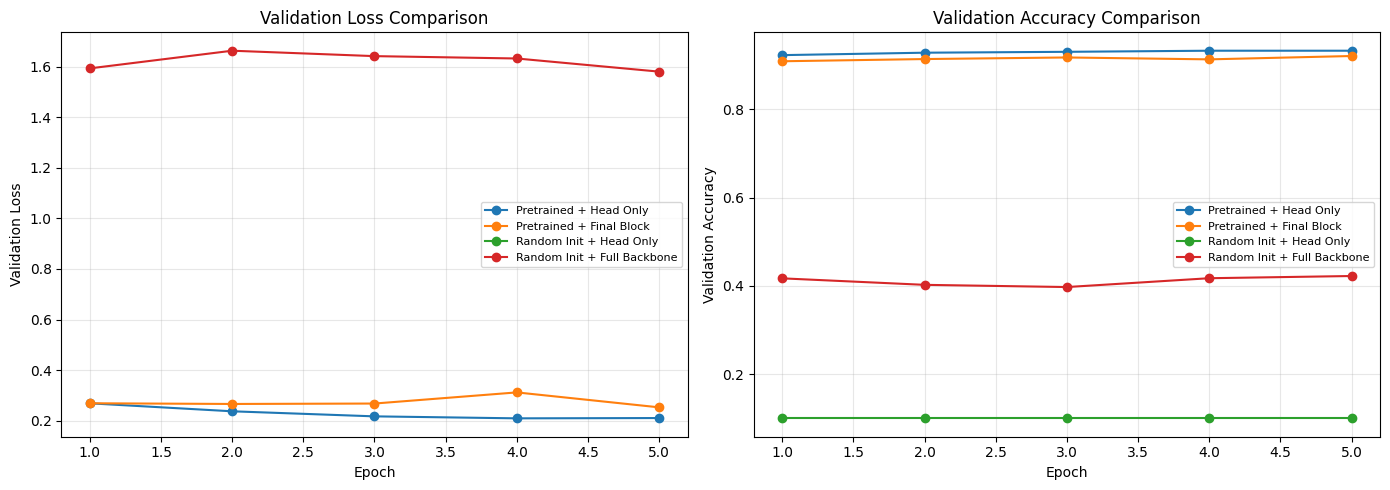

In [29]:
# === Comparison plots ===============================================
import matplotlib.pyplot as plt

results_1_4 = load_results()   # reload so this works in a fresh session

labels_1_4 = {
    "pretrained_head_only":   "Pretrained + Head Only",
    "pretrained_final_block": "Pretrained + Final Block",
    "random_head_only":       "Random Init + Head Only",
    "random_full_backbone":   "Random Init + Full Backbone",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for key in labels_1_4:
    if key not in results_1_4:
        print(f"missing: {key}"); continue
    hist = results_1_4[key]
    ep = range(1, len(hist["val_loss"]) + 1)
    axes[0].plot(ep, hist["val_loss"], marker='o', label=labels_1_4[key])
    axes[1].plot(ep, hist["val_acc"],  marker='o', label=labels_1_4[key])

axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Validation Loss")
axes[0].set_title("Validation Loss Comparison"); axes[0].legend(fontsize=8); axes[0].grid(alpha=.3)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Validation Accuracy")
axes[1].set_title("Validation Accuracy Comparison"); axes[1].legend(fontsize=8); axes[1].grid(alpha=.3)

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_DIR, 'task1_4_comparison.png'), dpi=150)
plt.show()


In [30]:
# === Summary table + LaTeX for the report ===========================
import pandas as pd

trainable_counts = {
    "pretrained_head_only":   20_490,
    "random_head_only":       20_490,
    "pretrained_final_block": 58_164_298 - 14_964_672,   # printed exactly by the run above
    "random_full_backbone":   58_164_298,
}

rows = []
for key, label in labels_1_4.items():
    if key not in results_1_4:
        continue
    h = results_1_4[key]
    rows.append({
        "Experiment":      label,
        "Trainable params": f"{trainable_counts.get(key, 0):,}",
        "Final Train Acc": f"{h['train_acc'][-1]:.4f}",
        "Final Val Acc":   f"{h['val_acc'][-1]:.4f}",
        "Best Val Acc":    f"{max(h['val_acc']):.4f}",
        "Final Val Loss":  f"{h['val_loss'][-1]:.4f}",
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))
df.to_csv(os.path.join(DRIVE_DIR, 'task1_4_summary.csv'), index=False)

latex = df.to_latex(index=False, escape=False,
                    caption="Transfer learning comparison on CIFAR-10 "
                            f"({CFG['train_subset']} train / {CFG['val_subset']} val, "
                            f"{CFG['img_size']}px, {CFG['epochs']} epochs).",
                    label="tab:task1_4")
with open(os.path.join(DRIVE_DIR, 'task1_4_table.tex'), 'w') as f:
    f.write(latex)
print("\n" + latex)


                 Experiment Trainable params Final Train Acc Final Val Acc Best Val Acc Final Val Loss
     Pretrained + Head Only           20,490          0.9775        0.9330       0.9330         0.2103
   Pretrained + Final Block       43,199,626          0.9269        0.9210       0.9210         0.2526
    Random Init + Head Only           20,490          0.1000        0.1000       0.1000            nan
Random Init + Full Backbone       58,164,298          0.4538        0.4225       0.4225         1.5802

\begin{table}
\caption{Transfer learning comparison on CIFAR-10 (10000 train / 2000 val, 160px, 5 epochs).}
\label{tab:task1_4}
\begin{tabular}{llllll}
\toprule
Experiment & Trainable params & Final Train Acc & Final Val Acc & Best Val Acc & Final Val Loss \\
\midrule
Pretrained + Head Only & 20,490 & 0.9775 & 0.9330 & 0.9330 & 0.2103 \\
Pretrained + Final Block & 43,199,626 & 0.9269 & 0.9210 & 0.9210 & 0.2526 \\
Random Init + Head Only & 20,490 & 0.1000 & 0.1000 & 0.1000 & nan \

# Task 1.5:

### Part a)

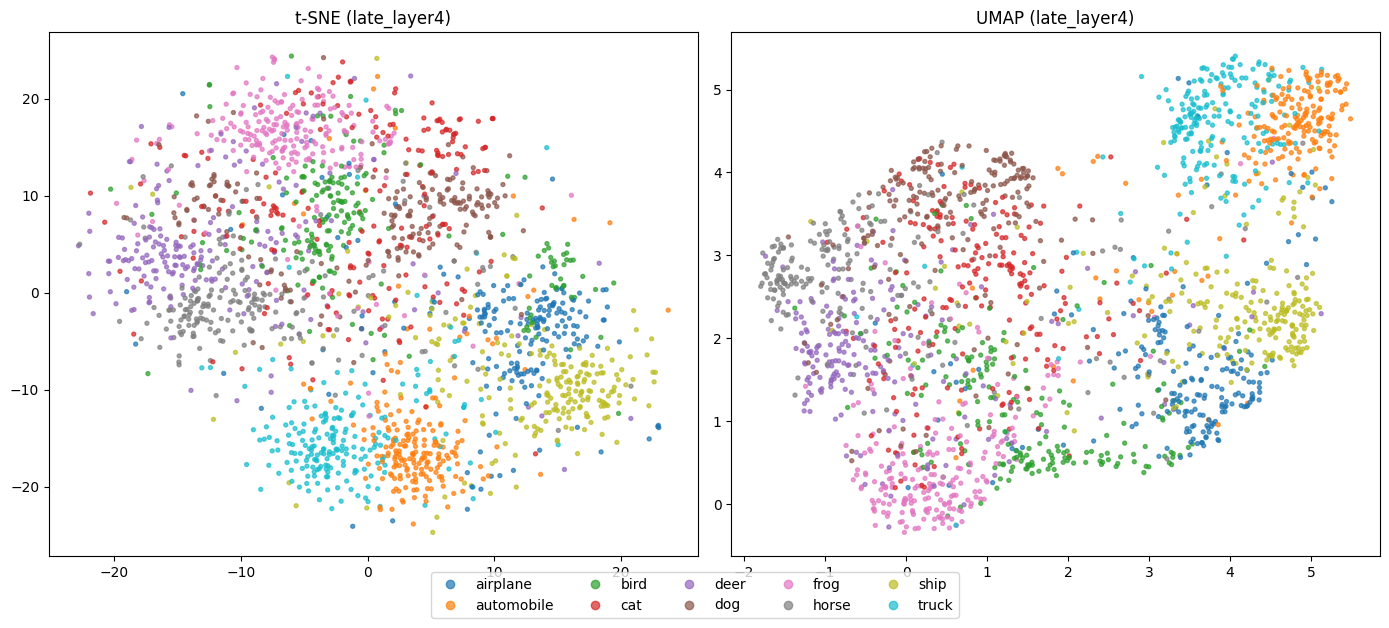

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

key = 'late_layer4'  # most informative layer for this comparison

scatter1 = axes[0].scatter(tsne_results[key][:, 0], tsne_results[key][:, 1],
                            c=all_labels, cmap='tab10', s=8, alpha=0.7)
axes[0].set_title("t-SNE (late_layer4)")

scatter2 = axes[1].scatter(umap_results[key][:, 0], umap_results[key][:, 1],
                            c=all_labels, cmap='tab10', s=8, alpha=0.7)
axes[1].set_title("UMAP (late_layer4)")

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
handles, _ = scatter1.legend_elements()
fig.legend(handles, class_names, loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ATML_PA0/task1_5a_tsne_vs_umap.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
print("Silhouette score comparison (higher = tighter, more separated clusters):\n")
print(f"{'Layer':<20}{'t-SNE':<10}{'UMAP':<10}")
for k in ['early_layer1', 'middle_layer3', 'late_layer4']:
    tsne_score = silhouette_score(tsne_results[k], all_labels)
    umap_score = silhouette_score(umap_results[k], all_labels)
    print(f"{k:<20}{tsne_score:<10.4f}{umap_score:<10.4f}")

Silhouette score comparison (higher = tighter, more separated clusters):

Layer               t-SNE     UMAP      
early_layer1        -0.1258   -0.1253   
middle_layer3       -0.0846   -0.0827   
late_layer4         0.0319    0.0629    


### Part b)

In [33]:
model.eval()
all_preds = []
all_true = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(labels.numpy())

all_preds = np.array(all_preds)
all_true = np.array(all_true)

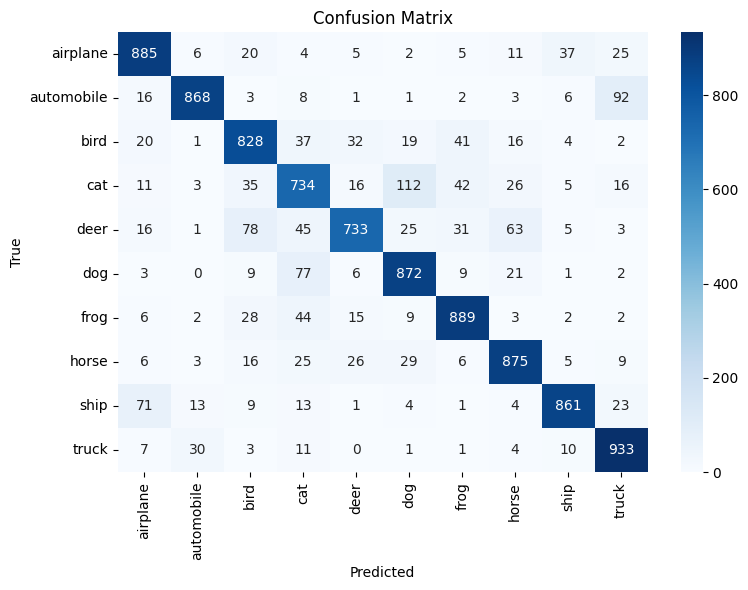

Most confused pair: 'cat' predicted as 'dog' (112 times)


In [34]:
cm = confusion_matrix(all_true, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ATML_PA0/task1_5b_confusion_matrix.png', dpi=150)
plt.show()

# Find the most-confused pair (highest off-diagonal count)
cm_off_diag = cm.copy()
np.fill_diagonal(cm_off_diag, 0)
i, j = np.unravel_index(cm_off_diag.argmax(), cm_off_diag.shape)
print(f"Most confused pair: '{class_names[i]}' predicted as '{class_names[j]}' ({cm_off_diag[i,j]} times)")

In [35]:
from scipy.spatial.distance import cdist

def class_feature_stats(feats, labels, class_a_idx, class_b_idx):
    feats_a = feats[labels == class_a_idx]
    feats_b = feats[labels == class_b_idx]

    # Mean pairwise cosine distance between the two classes' features
    dists = cdist(feats_a, feats_b, metric='cosine')
    mean_dist = dists.mean()

    # Intra-class compactness (average distance to own class centroid)
    centroid_a = feats_a.mean(axis=0)
    centroid_b = feats_b.mean(axis=0)
    intra_a = np.mean(cdist(feats_a, centroid_a.reshape(1, -1), metric='cosine'))
    intra_b = np.mean(cdist(feats_b, centroid_b.reshape(1, -1), metric='cosine'))

    return mean_dist, intra_a, intra_b

# Use the most-confused pair found above
class_a_idx, class_b_idx = i, j

print(f"Comparing '{class_names[class_a_idx]}' vs '{class_names[class_b_idx]}' (confused pair):\n")
for layer_key in ['early_layer1', 'middle_layer3', 'late_layer4']:
    inter_dist, intra_a, intra_b = class_feature_stats(
        all_features[layer_key], all_labels, class_a_idx, class_b_idx
    )
    print(f"{layer_key}: inter-class dist={inter_dist:.4f}, "
          f"intra-class dist (a)={intra_a:.4f}, intra-class dist (b)={intra_b:.4f}")

Comparing 'cat' vs 'dog' (confused pair):

early_layer1: inter-class dist=0.0308, intra-class dist (a)=0.0153, intra-class dist (b)=0.0155
middle_layer3: inter-class dist=0.0487, intra-class dist (a)=0.0245, intra-class dist (b)=0.0236
late_layer4: inter-class dist=0.6711, intra-class dist (a)=0.3997, intra-class dist (b)=0.4150


### Part c)

In [36]:
model_r18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model_r18 = model_r18.to(device)
model_r18.eval()

features_r18 = {}

def get_hook_r18(name):
    def hook(module, input, output):
        pooled = torch.nn.functional.adaptive_avg_pool2d(output, (1, 1))
        features_r18[name] = pooled.squeeze(-1).squeeze(-1).detach().cpu()
    return hook

# ResNet-18 has the same named layer structure (layer1-4), just fewer blocks per layer
hooks_r18 = []
hooks_r18.append(model_r18.layer1.register_forward_hook(get_hook_r18('early_layer1')))
hooks_r18.append(model_r18.layer3.register_forward_hook(get_hook_r18('middle_layer3')))
hooks_r18.append(model_r18.layer4.register_forward_hook(get_hook_r18('late_layer4')))

all_features_r18 = {'early_layer1': [], 'middle_layer3': [], 'late_layer4': []}
all_labels_r18 = []

collected = 0
num_samples_target = 2000
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        _ = model_r18(images)

        for key in all_features_r18:
            all_features_r18[key].append(features_r18[key])
        all_labels_r18.append(labels)

        collected += images.size(0)
        if collected >= num_samples_target:
            break

for key in all_features_r18:
    all_features_r18[key] = torch.cat(all_features_r18[key], dim=0).numpy()
all_labels_r18 = torch.cat(all_labels_r18, dim=0).numpy()

for h in hooks_r18:
    h.remove()

print("ResNet-18 features extracted:", {k: v.shape for k, v in all_features_r18.items()})

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 126MB/s]


ResNet-18 features extracted: {'early_layer1': (2048, 64), 'middle_layer3': (2048, 256), 'late_layer4': (2048, 512)}


In [37]:
print("Silhouette score comparison (class separability):\n")
print(f"{'Layer':<20}{'ResNet-152':<15}{'ResNet-18':<15}")
for k in ['early_layer1', 'middle_layer3', 'late_layer4']:
    score_152 = silhouette_score(all_features[k], all_labels)
    score_18 = silhouette_score(all_features_r18[k], all_labels_r18)
    print(f"{k:<20}{score_152:<15.4f}{score_18:<15.4f}")

Silhouette score comparison (class separability):

Layer               ResNet-152     ResNet-18      
early_layer1        -0.0584        -0.0419        
middle_layer3       0.0000         -0.0036        
late_layer4         0.0114         0.0222         


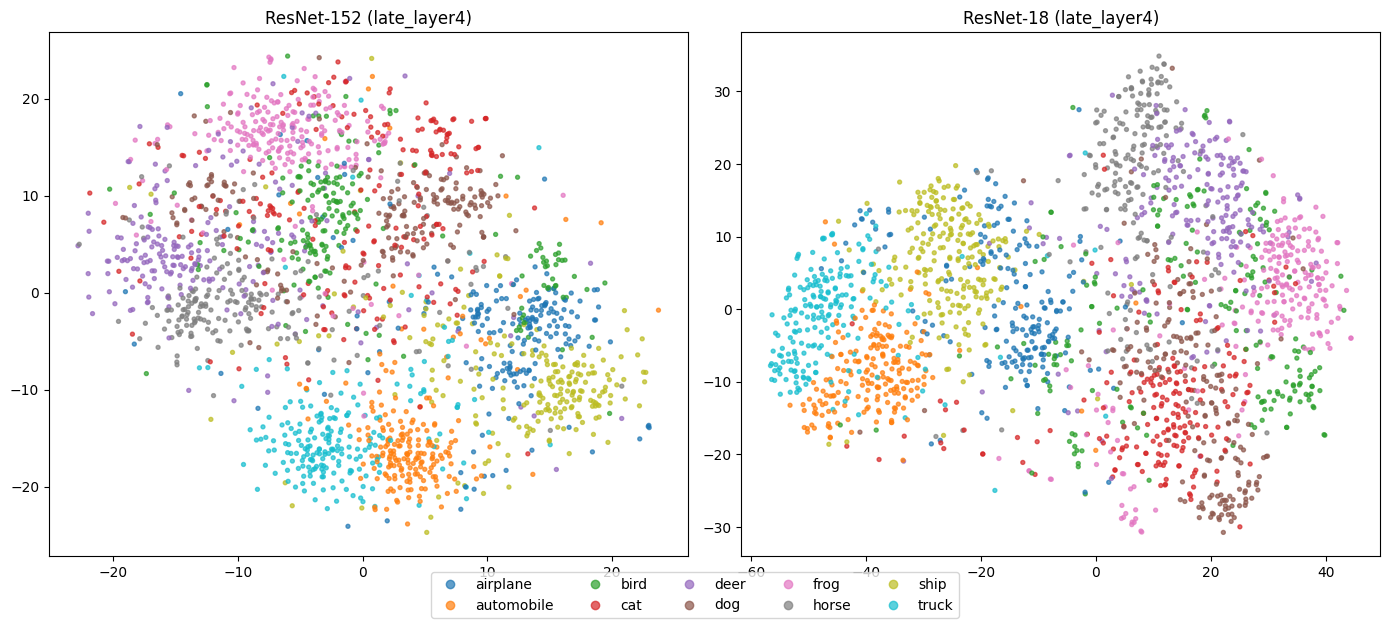

In [38]:
tsne_r18_late = TSNE(n_components=2, perplexity=30, random_state=42, init='pca').fit_transform(
    all_features_r18['late_layer4']
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter1 = axes[0].scatter(tsne_results['late_layer4'][:, 0], tsne_results['late_layer4'][:, 1],
                            c=all_labels, cmap='tab10', s=8, alpha=0.7)
axes[0].set_title("ResNet-152 (late_layer4)")

scatter2 = axes[1].scatter(tsne_r18_late[:, 0], tsne_r18_late[:, 1],
                            c=all_labels_r18, cmap='tab10', s=8, alpha=0.7)
axes[1].set_title("ResNet-18 (late_layer4)")

handles, _ = scatter1.legend_elements()
fig.legend(handles, class_names, loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ATML_PA0/task1_5c_resnet152_vs_18.png', dpi=150, bbox_inches='tight')
plt.show()